# Análise Exploratória de Dados - Focos de Queimadas no Brasil em 2025

**Projeto Aplicado I | Banco de Dados | Universidade Presbiteriana Mackenzie**

## Sobre o projeto

Este notebook apresenta uma análise exploratória dos registros de focos de
queimadas no Brasil durante o ano de 2025.

O trabalho utiliza dados do Programa Queimadas, do Instituto Nacional de
Pesquisas Espaciais (INPE), e tem como objetivo conhecer as principais
características do conjunto de dados, verificar aspectos relacionados à
qualidade das informações e analisar a distribuição dos registros ao longo
do tempo e do território brasileiro.

Também são analisadas algumas variáveis ambientais presentes na base, como
número de dias sem chuva, precipitação, risco de fogo e FRP.

Os resultados desta etapa serão utilizados como apoio para a definição da
proposta analítica do Projeto Aplicado I.

**Dataset:** `focos_br_todos-sats_2025.csv`

**Fonte:** Instituto Nacional de Pesquisas Espaciais (INPE) - Programa Queimadas.

**Ferramentas utilizadas:** Python, Pandas, NumPy e Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# Caminho do dataset
caminho = Path("../data/raw/focos_br_todos-sats_2025.csv")

In [3]:
# Carregamento do dataset
df = pd.read_csv(caminho, low_memory=False)

## 1. Estrutura e tipos de dados

Nesta etapa são verificadas as dimensões do dataset, os nomes das variáveis e
os tipos de dados utilizados em cada coluna.

In [4]:
# Dimensões do dataset
df.shape

(3466399, 13)

**Dimensões do conjunto de dados**

O conjunto de dados possui 3.466.399 registros e 13 variáveis.

In [5]:
# Nomes das variáveis
df.columns.tolist()

['latitude',
 'longitude',
 'data_pas',
 'satelite',
 'pais',
 'estado',
 'municipio',
 'bioma',
 'numero_dias_sem_chuva',
 'precipitacao',
 'risco_fogo',
 'id_area_industrial',
 'frp']

In [6]:
# Visão inicial dos registros
df.head()

,latitude,longitude,data_pas,satelite,pais,estado,municipio,bioma,numero_dias_sem_chuva,precipitacao,risco_fogo,id_area_industrial,frp
0,-19.7334,-55.399899,2025-01-01 00:35:00,METOP-B,Brasil,MATO GROSSO DO SUL,AQUIDAUANA,Pantanal,7.0,0.00,0.74,0,NaN
1,-15.2145,-60.173901,2025-01-01 00:38:00,METOP-B,Brasil,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,4.0,0.72,0.65,0,NaN
2,-15.2090,-60.198799,2025-01-01 00:38:00,METOP-B,Brasil,MATO GROSSO,VILA BELA DA SANTÍSSIMA TRINDADE,Amazônia,3.0,1.32,0.58,0,NaN
3,-12.2099,-49.326199,2025-01-01 00:38:00,METOP-B,Brasil,TOCANTINS,FIGUEIRÓPOLIS,Cerrado,1.0,0.00,0.10,0,NaN
4,-12.2082,-49.318901,2025-01-01 00:38:00,METOP-B,Brasil,TOCANTINS,FIGUEIRÓPOLIS,Cerrado,1.0,0.00,0.14,0,NaN


In [7]:
# Tipos de dados e informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3466399 entries, 0 to 3466398
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   latitude               float64
 1   longitude              float64
 2   data_pas               str    
 3   satelite               str    
 4   pais                   str    
 5   estado                 str    
 6   municipio              str    
 7   bioma                  str    
 8   numero_dias_sem_chuva  float64
 9   precipitacao           float64
 10  risco_fogo             float64
 11  id_area_industrial     int64  
 12  frp                    float64
dtypes: float64(6), int64(1), str(6)
memory usage: 343.8 MB


In [8]:
# Tipos de dados de cada variável
df.dtypes

latitude                 float64
longitude                float64
data_pas                     str
satelite                     str
pais                         str
estado                       str
municipio                    str
bioma                        str
numero_dias_sem_chuva    float64
precipitacao             float64
risco_fogo               float64
id_area_industrial         int64
frp                      float64
dtype: object

## 2. Exploração inicial e qualidade dos dados

Nesta etapa são verificados valores ausentes, registros duplicados e outras
características relacionadas à qualidade dos dados. Também são realizadas
análises iniciais das variáveis categóricas e da variável temporal.

In [9]:
# Quantidade de valores ausentes por variável
df.isna().sum()

latitude                     0
longitude                    0
data_pas                     0
satelite                     0
pais                         0
estado                       0
municipio                    0
bioma                        3
numero_dias_sem_chuva    58485
precipitacao             58485
risco_fogo               58485
id_area_industrial           0
frp                      45481
dtype: int64

In [10]:
# Percentual de valores ausentes por variável
percentual_nulos = (df.isna().mean() * 100).sort_values(ascending=False)

percentual_nulos

numero_dias_sem_chuva    1.687198
precipitacao             1.687198
risco_fogo               1.687198
frp                      1.312053
bioma                    0.000087
pais                     0.000000
satelite                 0.000000
data_pas                 0.000000
longitude                0.000000
latitude                 0.000000
municipio                0.000000
estado                   0.000000
id_area_industrial       0.000000
dtype: float64

In [11]:
# Quantidade de registros duplicados
df.duplicated().sum()

np.int64(585)

**Observação sobre os registros duplicados**

Foram identificados 585 registros duplicados no conjunto de dados. Nesta etapa,
esses registros foram mantidos, pois a análise exploratória não permite afirmar
que representam erros na base original.

In [12]:
# Resumo das variáveis
resumo_variaveis = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(dropna=True),
    "valores_nulos": df.isna().sum(),
    "percentual_nulos": (df.isna().mean() * 100).round(2)
})

resumo_variaveis

,tipo,valores_unicos,valores_nulos,percentual_nulos
latitude,float64,1509574,0,0.00
longitude,float64,1533280,0,0.00
data_pas,str,53448,0,0.00
satelite,str,13,0,0.00
pais,str,1,0,0.00
estado,str,27,0,0.00
municipio,str,5240,0,0.00
bioma,str,6,3,0.00
numero_dias_sem_chuva,float64,122,58485,1.69
precipitacao,float64,4911,58485,1.69


In [13]:
# Distribuição da variável id_area_industrial
df["id_area_industrial"].value_counts(dropna=False).sort_index()

id_area_industrial
0    3466399
Name: count, dtype: int64

**Observação sobre a variável `id_area_industrial`**

A variável `id_area_industrial` apresentou apenas o valor 0 em todos os
registros do conjunto de dados. Dessa forma, essa variável não apresenta
variação na base analisada.

### 2.1 Distribuição das variáveis categóricas

Nesta etapa são analisadas as frequências das principais variáveis
categóricas do dataset, buscando identificar sua distribuição e possíveis
valores ausentes ou concentrações relevantes.

In [14]:
# Frequência de registros por bioma
df["bioma"].value_counts(dropna=False)

bioma
Cerrado           1784865
Amazônia           975655
Caatinga           445091
Mata Atlântica     219855
Pantanal            28936
Pampa               11994
NaN                     3
Name: count, dtype: int64

In [15]:
# Frequência de registros por estado
df["estado"].value_counts()

estado
MARANHÃO               588744
TOCANTINS              407909
MATO GROSSO            384854
PIAUÍ                  366446
PARÁ                   332780
BAHIA                  307664
MINAS GERAIS           194643
GOIÁS                  182889
AMAZONAS               142928
CEARÁ                   94142
MATO GROSSO DO SUL      58357
RONDÔNIA                58213
SÃO PAULO               56511
RORAIMA                 44508
ACRE                    44255
PERNAMBUCO              38554
RIO GRANDE DO SUL       26895
PARANÁ                  26395
SANTA CATARINA          20051
PARAÍBA                 19072
AMAPÁ                   18905
RIO GRANDE DO NORTE     14436
RIO DE JANEIRO          10735
ALAGOAS                  9916
ESPÍRITO SANTO           7279
SERGIPE                  4865
DISTRITO FEDERAL         4453
Name: count, dtype: int64

In [16]:
# Frequência de registros por satélite
df["satelite"].value_counts()

satelite
NOAA-20      833657
NOAA-21      816238
GOES-19      683118
NPP-375      589783
NPP-375D     250951
AQUA_M-T     136393
TERRA_M-M     47318
TERRA_M-T     39188
METOP-B       23047
METOP-C       22138
GOES-16       12418
AQUA_M-M      11907
MSG-03          243
Name: count, dtype: int64

In [17]:
# Valores presentes na variável país
df["pais"].value_counts(dropna=False)

pais
Brasil    3466399
Name: count, dtype: int64

### 2.2 Análise da variável temporal

A variável `data_pas` contém a data e o horário associados a cada registro de foco.
Nesta etapa, a variável será convertida para o formato de data/hora para permitir
a análise temporal dos registros durante o ano de 2025.

In [18]:
# Conversão da variável temporal para o formato de data/hora
df["data_pas_dt"] = pd.to_datetime(df["data_pas"], errors="coerce")

In [19]:
# Quantidade de datas que não puderam ser convertidas
df["data_pas_dt"].isna().sum()

np.int64(0)

In [20]:
# Período coberto pelo dataset
print("Data inicial:", df["data_pas_dt"].min())
print("Data final:", df["data_pas_dt"].max())

Data inicial: 2025-01-01 00:00:00
Data final: 2025-12-31 23:50:00


In [21]:
# Distribuição mensal dos registros
registros_por_mes = (
    df["data_pas_dt"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

tabela_mensal = pd.DataFrame({
    "mes": registros_por_mes.index.astype(str),
    "registros": registros_por_mes.values
})

tabela_mensal["percentual"] = (
    tabela_mensal["registros"] / len(df) * 100
).round(2)

tabela_mensal

,mes,registros,percentual
0,2025-01,63439,1.83
1,2025-02,41395,1.19
2,2025-03,49888,1.44
3,2025-04,29801,0.86
4,2025-05,107679,3.11
5,2025-06,168163,4.85
6,2025-07,243608,7.03
7,2025-08,594309,17.14
8,2025-09,833039,24.03
9,2025-10,823767,23.76


#### 2.2.1 Visualização da distribuição mensal

A distribuição mensal dos registros permite observar como os registros estão
concentrados ao longo do ano de 2025. A visualização auxilia
na identificação de períodos com maior e menor quantidade de registros.

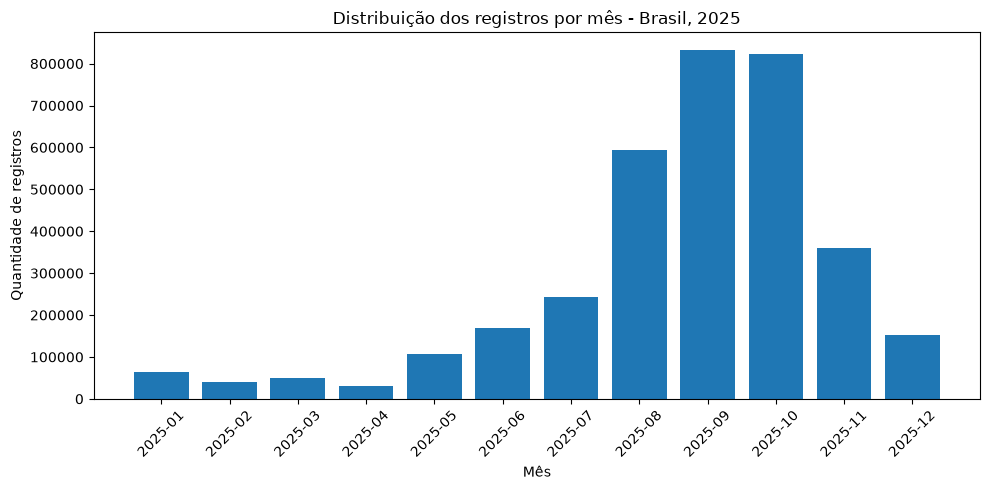

In [22]:
# Gráfico da quantidade de registros por mês

plt.figure(figsize=(10, 5))

plt.bar(
    tabela_mensal["mes"],
    tabela_mensal["registros"]
)

plt.title("Distribuição dos registros por mês - Brasil, 2025")
plt.xlabel("Mês")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Estatística descritiva das variáveis numéricas

Nesta etapa são analisadas as principais medidas estatísticas das variáveis
numéricas do conjunto de dados, incluindo quantidade de valores válidos,
média, mediana, valores mínimo e máximo, desvio padrão e variância.

Também são verificadas a distribuição dos valores, a presença de valores
ausentes e a existência de possíveis outliers.

In [23]:
# Seleção das variáveis numéricas
variaveis_numericas = df.select_dtypes(include=np.number).columns

# Estatística descritiva
estatistica_descritiva = df[variaveis_numericas].describe().T

In [24]:
# Inclusão da variância na estatística descritiva
estatistica_descritiva["variancia"] = df[variaveis_numericas].var()

estatistica_descritiva

,count,mean,std,min,25%,50%,75%,max,variancia
latitude,3466399.0,-9.922405,5.634602,-33.73760,-12.94972,-9.18419,-6.154920,5.16388,31.748737
longitude,3466399.0,-48.580182,6.597502,-73.66169,-51.49690,-46.99940,-44.179794,-34.79972,43.527034
numero_dias_sem_chuva,3407914.0,9.885655,112.338336,-999.00000,4.00000,9.00000,29.000000,120.00000,12619.901644
precipitacao,3407914.0,0.510339,2.578257,0.00000,0.00000,0.00000,0.000000,158.76000,6.647410
risco_fogo,3407914.0,-7.282407,89.582648,-999.00000,0.70000,1.00000,1.000000,1.00000,8025.050864
id_area_industrial,3466399.0,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000
frp,3420918.0,35.940430,70.788137,0.00000,3.90000,9.00000,41.700000,12311.30000,5010.960299


**Observação sobre a estatística inicial**

Os resultados apresentados acima correspondem aos dados antes do tratamento
dos valores inválidos. Por isso, algumas medidas estatísticas podem ser
influenciadas pela presença do valor -999.

Nas etapas seguintes esses valores serão identificados e tratados, e a
estatística descritiva será calculada novamente.

### 3.1 Identificação de valores especiais

Nesta etapa são investigados valores que possam representar códigos
especiais, valores inválidos ou situações distintas dos valores
observacionais esperados para cada variável.

In [25]:
# Frequência do valor -999 nas variáveis ambientais
print("numero_dias_sem_chuva:")
print((df["numero_dias_sem_chuva"] == -999).sum())

print("\nrisco_fogo:")
print((df["risco_fogo"] == -999).sum())

numero_dias_sem_chuva:
39383

risco_fogo:
27582


In [26]:
# Valores mais frequentes em risco_fogo
df["risco_fogo"].value_counts(dropna=False).head(20)

risco_fogo
 1.00      1971403
 NaN         58485
 0.00        51869
 0.99        48619
 0.98        39302
 0.97        34373
 0.01        34332
 0.96        29766
-999.00      27582
 0.95        27286
 0.94        25910
 0.02        23757
 0.93        23035
 0.92        22936
 0.91        20414
 0.90        19834
 0.03        19205
 0.89        18876
 0.86        17925
 0.88        17908
Name: count, dtype: int64

In [27]:
# Valores mais frequentes em numero_dias_sem_chuva
df["numero_dias_sem_chuva"].value_counts(dropna=False).head(20)

numero_dias_sem_chuva
 2.0      240191
 3.0      233374
 0.0      217925
 4.0      205850
 5.0      179892
 6.0      152711
 7.0      138441
 8.0      122332
 9.0      110872
 10.0      86463
 11.0      72157
 1.0       67602
 12.0      64483
 13.0      59575
 NaN       58485
 14.0      53129
 15.0      45777
 16.0      44266
 17.0      43189
-999.0     39383
Name: count, dtype: int64

### 3.2 Resumo dos valores ausentes e especiais

As variáveis ambientais apresentam valores ausentes e, em algumas delas,
também são observados registros com o valor -999. Nesta etapa, essas
ocorrências são quantificadas separadamente para apoiar a decisão sobre
seu tratamento nas análises posteriores.

In [28]:
# Resumo de valores ausentes e do código -999
variaveis_ambientais = [
    "numero_dias_sem_chuva",
    "precipitacao",
    "risco_fogo",
    "frp"
]

resumo_ambiental = pd.DataFrame({
    "valores_nulos": df[variaveis_ambientais].isna().sum(),
    "percentual_nulos": (df[variaveis_ambientais].isna().mean() * 100).round(2),
    "valor_-999": [(df[col] == -999).sum() for col in variaveis_ambientais],
})

resumo_ambiental["percentual_-999"] = (
    resumo_ambiental["valor_-999"] / len(df) * 100
).round(2)

resumo_ambiental

,valores_nulos,percentual_nulos,valor_-999,percentual_-999
numero_dias_sem_chuva,58485,1.69,39383,1.14
precipitacao,58485,1.69,0,0.00
risco_fogo,58485,1.69,27582,0.80
frp,45481,1.31,0,0.00


In [29]:
# Resumo da quantidade de variáveis ambientais ausentes por registro
quantidade_ausentes = df[variaveis_ambientais].isna().sum(axis=1)

pd.Series({
    "0 variáveis ausentes": (quantidade_ausentes == 0).sum(),
    "1 variável ausente": (quantidade_ausentes == 1).sum(),
    "2 variáveis ausentes": (quantidade_ausentes == 2).sum(),
    "3 variáveis ausentes": (quantidade_ausentes == 3).sum(),
    "4 variáveis ausentes": (quantidade_ausentes == 4).sum()
})

0 variáveis ausentes    3362940
1 variável ausente        44974
2 variáveis ausentes          0
3 variáveis ausentes      57978
4 variáveis ausentes        507
dtype: int64

In [30]:
# Variáveis ausentes nos registros que possuem apenas 1 ausência
ausentes_uma_variavel = df.loc[
    quantidade_ausentes == 1,
    variaveis_ambientais
].isna().sum()

ausentes_uma_variavel

numero_dias_sem_chuva        0
precipitacao                 0
risco_fogo                   0
frp                      44974
dtype: int64

In [31]:
# Identificação das variáveis ausentes nos registros com 3 ou 4 ausências

print("Registros com 3 variáveis ausentes:")
print(
    df.loc[
        quantidade_ausentes == 3,
        variaveis_ambientais
    ].isna().sum()
)

print("\nRegistros com 4 variáveis ausentes:")
print(
    df.loc[
        quantidade_ausentes == 4,
        variaveis_ambientais
    ].isna().sum()
)

Registros com 3 variáveis ausentes:
numero_dias_sem_chuva    57978
precipitacao             57978
risco_fogo               57978
frp                          0
dtype: int64

Registros com 4 variáveis ausentes:
numero_dias_sem_chuva    507
precipitacao             507
risco_fogo               507
frp                      507
dtype: int64


### 3.3 Preparação das variáveis para análise

Com base na documentação do Programa Queimadas do INPE, o valor -999 é
considerado inválido nas variáveis `numero_dias_sem_chuva`, `precipitacao`
e `risco_fogo`.

No conjunto de dados analisado, esse valor foi identificado nas variáveis
`numero_dias_sem_chuva` e `risco_fogo`, não sendo encontrado na variável
`precipitacao`.

Para evitar distorções nas análises estatísticas, foi criada uma cópia do
dataset para análise, preservando o conjunto original.

**Referência:** Programa Queimadas do INPE - documentação dos atributos do
Banco de Dados de Queimadas (BDQueimadas).

Disponível em:
https://terrabrasilis.dpi.inpe.br/queimadas/portal/pages/secao_informacoes/faq/

In [32]:
# Criação de uma cópia para as análises
df_eda = df.copy()

# Conversão dos valores inválidos -999 para valores ausentes
variaveis_999 = [
    "numero_dias_sem_chuva",
    "precipitacao",
    "risco_fogo"
]

df_eda[variaveis_999] = df_eda[variaveis_999].replace(-999, np.nan)

### 3.4 Estatística descritiva após o tratamento dos valores inválidos

Após a identificação dos valores especiais, os valores -999 encontrados nas
variáveis `numero_dias_sem_chuva` e `risco_fogo` foram tratados como ausentes
para as análises estatísticas.

Em seguida, a estatística descritiva foi recalculada utilizando a base
preparada para análise.

In [33]:
# Estatística descritiva da base preparada para análise
estatistica_eda = df_eda[variaveis_numericas].describe().T

# Inclusão da variância
estatistica_eda["variancia"] = df_eda[variaveis_numericas].var()

estatistica_eda

,count,mean,std,min,25%,50%,75%,max,variancia
latitude,3466399.0,-9.922405,5.634602,-33.73760,-12.94972,-9.18419,-6.154920,5.16388,31.748737
longitude,3466399.0,-48.580182,6.597502,-73.66169,-51.49690,-46.99940,-44.179794,-34.79972,43.527034
numero_dias_sem_chuva,3368531.0,21.680988,26.984648,0.00000,4.00000,10.00000,29.000000,120.00000,728.171220
precipitacao,3407914.0,0.510339,2.578257,0.00000,0.00000,0.00000,0.000000,158.76000,6.647410
risco_fogo,3380332.0,0.809566,0.312233,0.00000,0.71000,1.00000,1.000000,1.00000,0.097489
id_area_industrial,3466399.0,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,0.00000,0.000000
frp,3420918.0,35.940430,70.788137,0.00000,3.90000,9.00000,41.700000,12311.30000,5010.960299


### 3.5 Identificação de valores outliers

Nesta etapa são identificados possíveis valores outliers nas variáveis
`numero_dias_sem_chuva`, `precipitacao`, `risco_fogo` e `frp`.

As variáveis `latitude` e `longitude` não foram incluídas nesta análise por
representarem coordenadas geográficas. A variável `id_area_industrial` também
não foi considerada, pois apresentou apenas o valor 0 em todos os registros.

A análise busca identificar valores que estão mais afastados da distribuição
das demais observações e que podem precisar de uma avaliação mais detalhada.

In [34]:
# Variáveis selecionadas para análise de outliers
variaveis_outliers = [
    "numero_dias_sem_chuva",
    "precipitacao",
    "risco_fogo",
    "frp"
]

resultado_outliers = []

for coluna in variaveis_outliers:
    dados_validos = df_eda[coluna].dropna()

    q1 = dados_validos.quantile(0.25)
    q3 = dados_validos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = (
        (dados_validos < limite_inferior) |
        (dados_validos > limite_superior)
    )

    resultado_outliers.append({
        "variavel": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "quantidade_outliers": outliers.sum(),
        "percentual_outliers": round(outliers.mean() * 100, 2)
    })

tabela_outliers = pd.DataFrame(resultado_outliers)

tabela_outliers

,variavel,Q1,Q3,IQR,limite_inferior,limite_superior,quantidade_outliers,percentual_outliers
0,numero_dias_sem_chuva,4.00,29.0,25.00,-33.500,66.500,295503,8.77
1,precipitacao,0.00,0.0,0.00,0.000,0.000,579755,17.01
2,risco_fogo,0.71,1.0,0.29,0.275,1.435,397248,11.75
3,frp,3.90,41.7,37.80,-52.800,98.400,362488,10.60


#### 3.5.1 Observação sobre os valores outliers

Os valores identificados nesta análise representam possíveis outliers
estatísticos e não necessariamente erros nos dados. A interpretação deve
considerar a distribuição e as características de cada variável.

No caso da precipitação, os valores de Q1 e Q3 foram iguais a zero. Por esse
motivo, o critério utilizado classificou os valores acima de zero como
possíveis outliers. Esse resultado está relacionado à grande concentração de
registros com precipitação igual ou próxima de zero e deve ser interpretado
com cuidado.

### 3.6 Distribuição das variáveis numéricas

Nesta etapa são analisadas as distribuições das principais variáveis numéricas
do dataset por meio de gráficos. O objetivo é observar como os valores estão
concentrados e identificar diferenças no comportamento das variáveis.

#### 3.6.1 Distribuição da precipitação

A distribuição da precipitação permite observar como os valores dessa variável
estão concentrados entre os registros analisados.

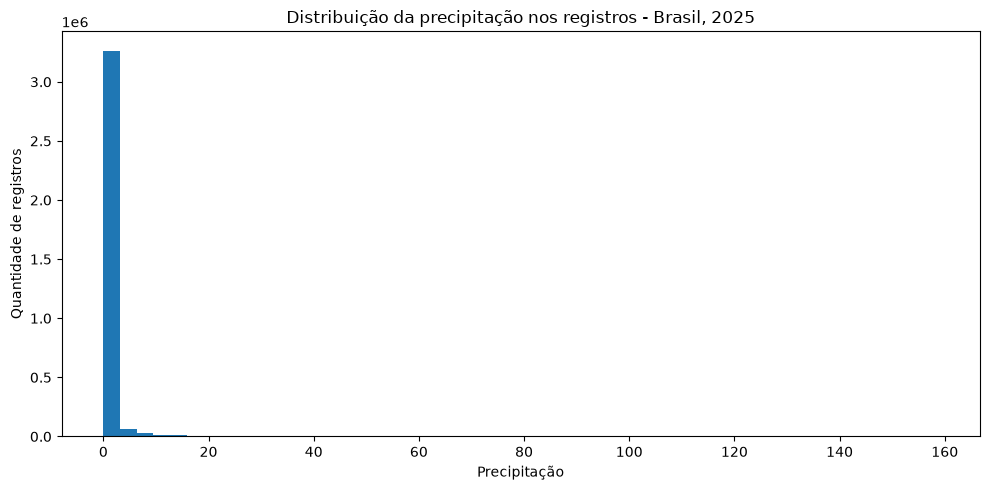

In [35]:
# Distribuição da precipitação

plt.figure(figsize=(10, 5))

plt.hist(
    df_eda["precipitacao"].dropna(),
    bins=50
)

plt.title("Distribuição da precipitação nos registros - Brasil, 2025")
plt.xlabel("Precipitação")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

#### 3.6.2 Observação sobre a precipitação

A distribuição da precipitação apresenta forte concentração de registros em
valores próximos de zero. Também são observados valores mais altos em uma
quantidade menor de registros, indicando uma distribuição com grande
concentração em valores baixos.

#### 3.6.3 Distribuição do risco de fogo

A distribuição do risco de fogo permite observar como os valores dessa
variável estão concentrados entre os registros analisados.

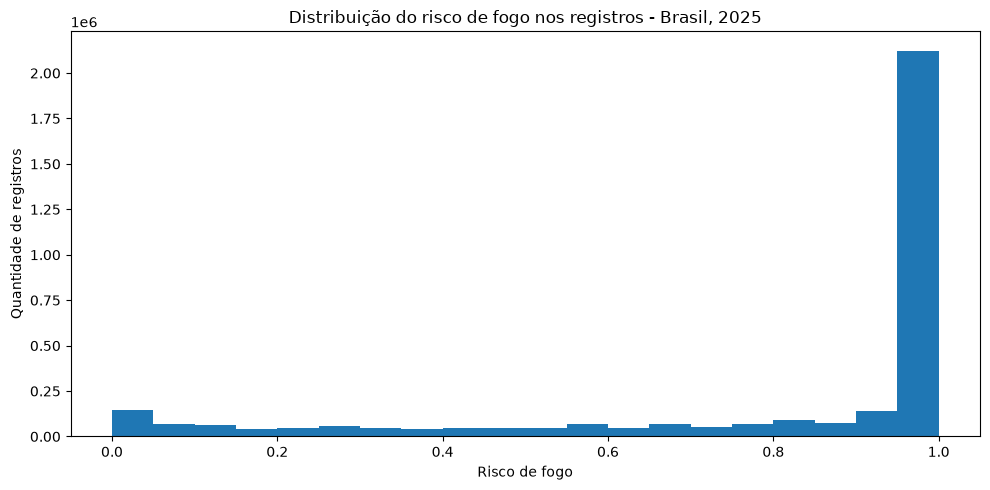

In [36]:
# Distribuição do risco de fogo

plt.figure(figsize=(10, 5))

plt.hist(
    df_eda["risco_fogo"].dropna(),
    bins=20
)

plt.title("Distribuição do risco de fogo nos registros - Brasil, 2025")
plt.xlabel("Risco de fogo")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

#### 3.6.4 Observação sobre o risco de fogo

A distribuição do risco de fogo apresenta forte concentração de registros no
valor 1,0. Os demais valores aparecem em quantidades menores ao longo do
intervalo entre 0 e 1.

#### 3.6.5 Distribuição do número de dias sem chuva

A distribuição do número de dias sem chuva permite observar como os valores
dessa variável estão concentrados entre os registros analisados.

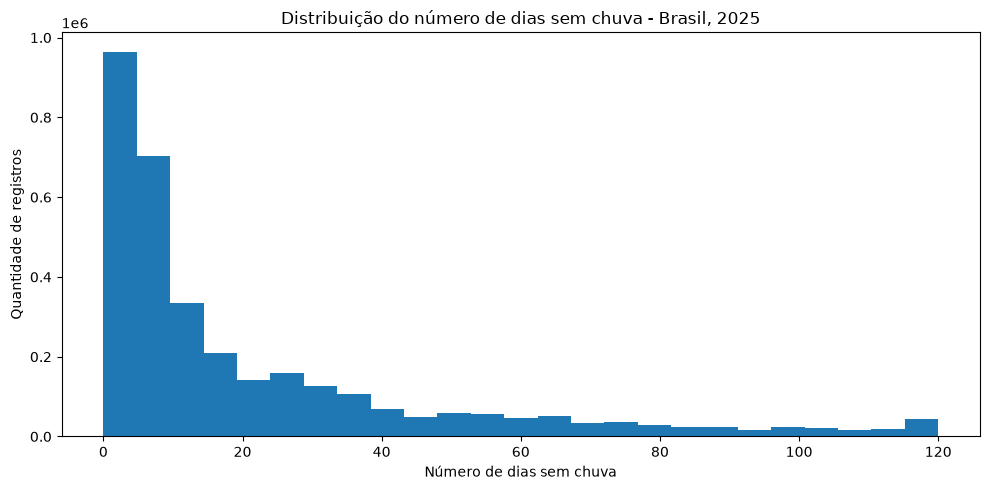

In [37]:
# Distribuição do número de dias sem chuva

plt.figure(figsize=(10, 5))

plt.hist(
    df_eda["numero_dias_sem_chuva"].dropna(),
    bins=25
)

plt.title("Distribuição do número de dias sem chuva - Brasil, 2025")
plt.xlabel("Número de dias sem chuva")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

#### 3.6.6 Observação sobre o número de dias sem chuva

A distribuição apresenta maior concentração de registros nos valores mais
baixos de dias sem chuva. A quantidade de registros diminui conforme aumenta
o número de dias sem chuva, com valores observados até 120 dias.

#### 3.6.7 Distribuição da FRP

A FRP (Fire Radiative Power), ou Potência Radiativa do Fogo, é uma medida
relacionada à intensidade do fogo detectado pelo satélite. Nesta etapa será
analisada a distribuição dos valores de FRP nos registros de queimadas de
2025, buscando observar como os valores estão concentrados e se existem
valores muito elevados.

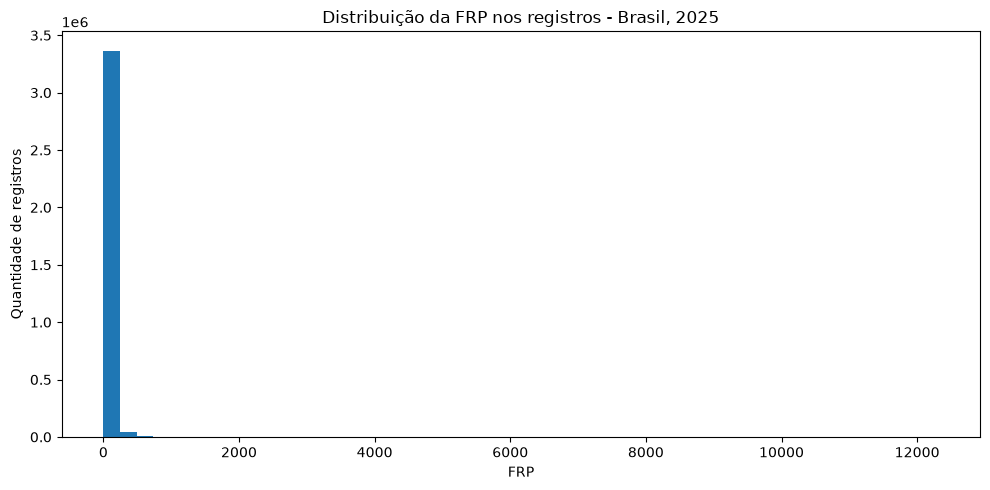

In [38]:
# Distribuição da FRP

plt.figure(figsize=(10, 5))

plt.hist(
    df_eda["frp"].dropna(),
    bins=50
)

plt.title("Distribuição da FRP nos registros - Brasil, 2025")
plt.xlabel("FRP")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

#### 3.6.8 Observação sobre a FRP

A distribuição da FRP apresenta grande concentração de registros nos valores
mais baixos, enquanto uma quantidade menor de registros apresenta valores
elevados. Conforme a estatística descritiva apresentada na seção 3.4, o maior
valor observado foi de 12.311,3.

## 4. Análise territorial dos focos

Nesta etapa são analisados os registros de focos de queimadas de acordo com sua
distribuição no território brasileiro. A análise considera estados, biomas e
municípios para identificar onde os registros estão mais concentrados.

### 4.1 Distribuição dos focos por estado

A distribuição dos registros por estado permite observar quais estados
apresentam maior e menor quantidade de registros no conjunto de dados
analisado.

In [39]:
# Distribuição dos registros por estado

registros_por_estado = (
    df_eda["estado"]
    .value_counts()
    .sort_values(ascending=False)
)

registros_por_estado

estado
MARANHÃO               588744
TOCANTINS              407909
MATO GROSSO            384854
PIAUÍ                  366446
PARÁ                   332780
BAHIA                  307664
MINAS GERAIS           194643
GOIÁS                  182889
AMAZONAS               142928
CEARÁ                   94142
MATO GROSSO DO SUL      58357
RONDÔNIA                58213
SÃO PAULO               56511
RORAIMA                 44508
ACRE                    44255
PERNAMBUCO              38554
RIO GRANDE DO SUL       26895
PARANÁ                  26395
SANTA CATARINA          20051
PARAÍBA                 19072
AMAPÁ                   18905
RIO GRANDE DO NORTE     14436
RIO DE JANEIRO          10735
ALAGOAS                  9916
ESPÍRITO SANTO           7279
SERGIPE                  4865
DISTRITO FEDERAL         4453
Name: count, dtype: int64

In [40]:
# Percentual de registros por estado

percentual_por_estado = (
    registros_por_estado / len(df_eda) * 100
).round(2)

percentual_por_estado

estado
MARANHÃO               16.98
TOCANTINS              11.77
MATO GROSSO            11.10
PIAUÍ                  10.57
PARÁ                    9.60
BAHIA                   8.88
MINAS GERAIS            5.62
GOIÁS                   5.28
AMAZONAS                4.12
CEARÁ                   2.72
MATO GROSSO DO SUL      1.68
RONDÔNIA                1.68
SÃO PAULO               1.63
RORAIMA                 1.28
ACRE                    1.28
PERNAMBUCO              1.11
RIO GRANDE DO SUL       0.78
PARANÁ                  0.76
SANTA CATARINA          0.58
PARAÍBA                 0.55
AMAPÁ                   0.55
RIO GRANDE DO NORTE     0.42
RIO DE JANEIRO          0.31
ALAGOAS                 0.29
ESPÍRITO SANTO          0.21
SERGIPE                 0.14
DISTRITO FEDERAL        0.13
Name: count, dtype: float64

In [41]:
# Resumo da distribuição dos registros por estado

tabela_estados = pd.DataFrame({
    "registros": registros_por_estado,
    "percentual": percentual_por_estado
})

tabela_estados.head(10)

,registros,percentual
estado,,
MARANHÃO,588744,16.98
TOCANTINS,407909,11.77
MATO GROSSO,384854,11.10
PIAUÍ,366446,10.57
PARÁ,332780,9.60
BAHIA,307664,8.88
MINAS GERAIS,194643,5.62
GOIÁS,182889,5.28
AMAZONAS,142928,4.12


#### 4.1.1 Visualização da distribuição por estado

A visualização dos registros por estado permite comparar a quantidade de
registros em cada unidade da federação e identificar diferenças na
distribuição dos registros.

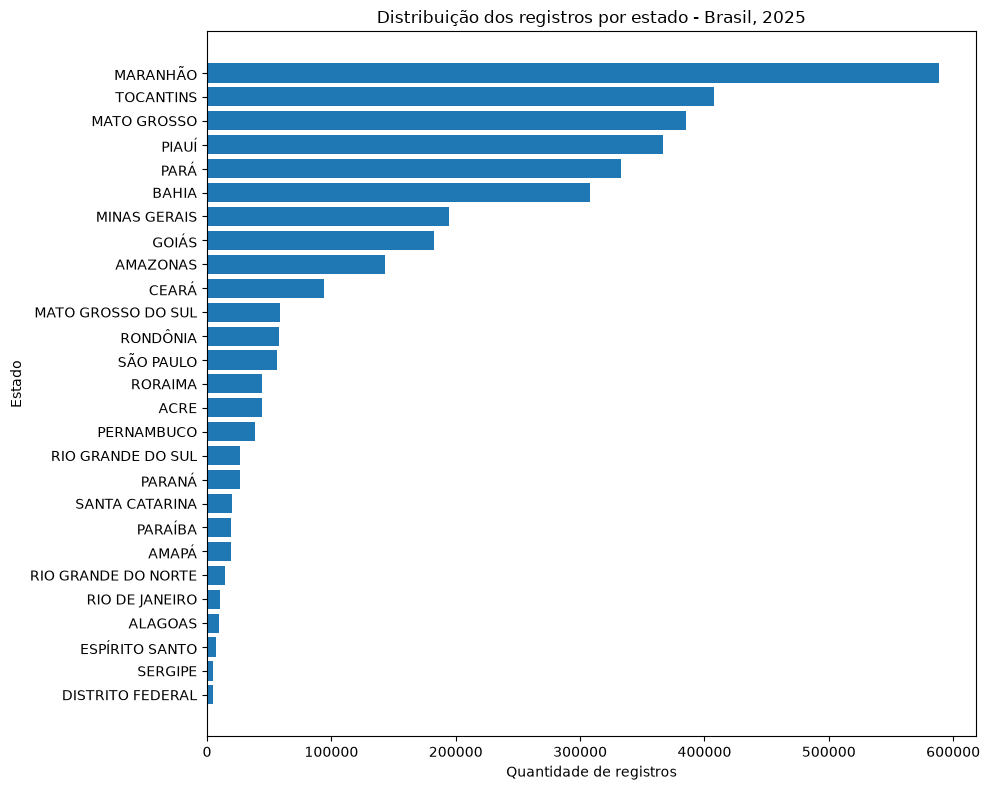

In [42]:
# Gráfico da distribuição dos registros por estado

plt.figure(figsize=(10, 8))

plt.barh(
    registros_por_estado.index[::-1],
    registros_por_estado.values[::-1]
)

plt.title("Distribuição dos registros por estado - Brasil, 2025")
plt.xlabel("Quantidade de registros")
plt.ylabel("Estado")

plt.tight_layout()
plt.show()

#### 4.1.2 Observação sobre a distribuição por estado

Conforme a tabela-resumo apresentada na seção 4.1, o Maranhão apresentou a
maior quantidade de registros, com 588.744 registros, correspondendo a 16,98%
do total analisado. Na sequência aparecem Tocantins, Mato Grosso, Piauí, Pará
e Bahia entre os estados com maior quantidade de registros.

O gráfico apresentado na seção 4.1.1 permite visualizar as diferenças na
quantidade de registros entre os estados ao longo de 2025.

### 4.2 Distribuição dos focos por bioma

A distribuição dos registros por bioma permite observar como os registros
estão distribuídos entre os diferentes biomas brasileiros e identificar onde
ocorre maior concentração de registros.

In [43]:
# Resumo da distribuição dos registros por bioma

registros_por_bioma = df_eda["bioma"].value_counts(dropna=False)

percentual_por_bioma = (
    registros_por_bioma / len(df_eda) * 100
).round(2)

tabela_biomas = pd.DataFrame({
    "registros": registros_por_bioma,
    "percentual": percentual_por_bioma
})

tabela_biomas

,registros,percentual
bioma,,
Cerrado,1784865,51.49
Amazônia,975655,28.15
Caatinga,445091,12.84
Mata Atlântica,219855,6.34
Pantanal,28936,0.83
Pampa,11994,0.35
NaN,3,0.00


#### 4.2.1 Visualização da distribuição por bioma

A visualização dos registros por bioma permite comparar a quantidade de
registros em cada bioma brasileiro e observar as diferenças entre eles.

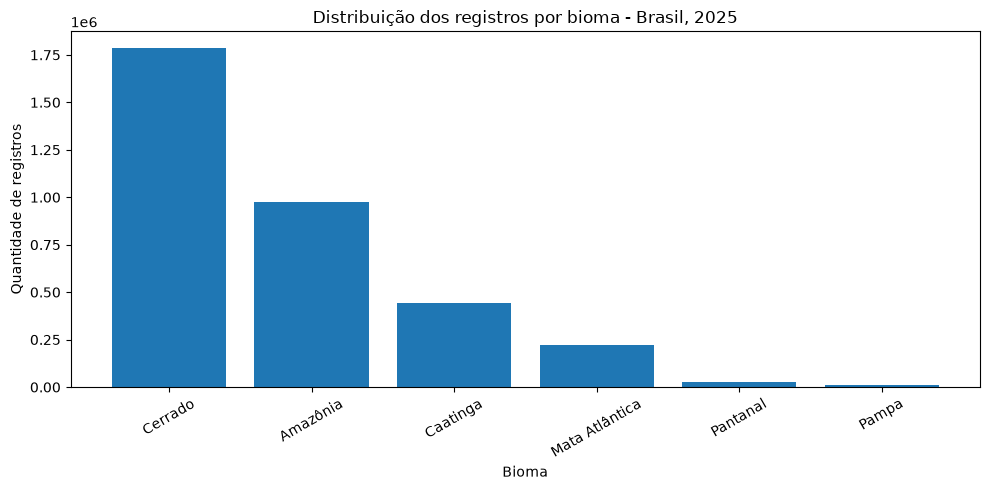

In [44]:
# Gráfico da distribuição dos registros por bioma

biomas_grafico = tabela_biomas[tabela_biomas.index.notna()]

plt.figure(figsize=(10, 5))

plt.bar(
    biomas_grafico.index,
    biomas_grafico["registros"]
)

plt.title("Distribuição dos registros por bioma - Brasil, 2025")
plt.xlabel("Bioma")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

#### 4.2.2 Observação sobre a distribuição por bioma

Conforme o resumo apresentado na seção 4.2, o Cerrado apresentou a maior
quantidade de registros, com 1.784.865 registros, correspondendo a 51,49% do
total analisado. Na sequência aparecem Amazônia, com 28,15%, e Caatinga,
com 12,84%.

O gráfico apresentado na seção 4.2.1 permite visualizar as diferenças na
quantidade de registros entre os biomas brasileiros em 2025.

### 4.3 Distribuição dos focos por município

Como o conjunto de dados possui um grande número de municípios, nesta etapa
serão analisados os municípios com maior quantidade de registros.

Para evitar a soma de municípios com o mesmo nome localizados em estados
diferentes, o agrupamento foi realizado utilizando as colunas `estado` e
`municipio`.

O objetivo é identificar quais municípios apresentam maior concentração de
registros no período analisado.

In [45]:
# Resumo dos 15 municípios com maior quantidade de registros
registros_por_municipio = (
    df_eda
    .groupby(["estado", "municipio"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

tabela_municipios = registros_por_municipio.reset_index(
    name="registros"
)

tabela_municipios["percentual"] = (
    tabela_municipios["registros"] / len(df_eda) * 100
).round(2)

tabela_municipios

,estado,municipio,registros,percentual
0,MATO GROSSO,COLNIZA,42141,1.22
1,MARANHÃO,MIRADOR,38521,1.11
2,TOCANTINS,PARANÃ,33659,0.97
3,MARANHÃO,BALSAS,30721,0.89
4,AMAZONAS,APUÍ,27220,0.79
5,MARANHÃO,ALTO PARNAÍBA,26362,0.76
6,TOCANTINS,LAGOA DA CONFUSÃO,24354,0.70
7,PIAUÍ,URUÇUÍ,24025,0.69
8,BAHIA,FORMOSA DO RIO PRETO,23656,0.68
9,BAHIA,SÃO DESIDÉRIO,23548,0.68


#### 4.3.1 Visualização dos municípios com maior quantidade de registros

A visualização dos municípios com maior quantidade de registros permite
comparar os principais municípios identificados na análise e observar as
diferenças na quantidade de registros entre eles.

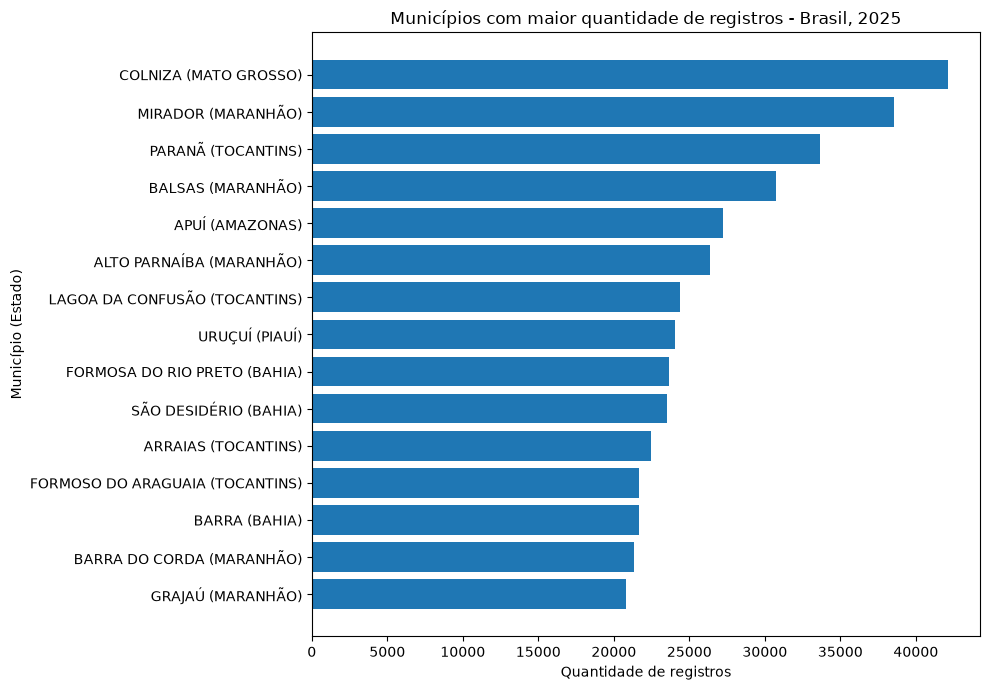

In [46]:
# Gráfico dos municípios com maior quantidade de registros

rotulos_municipios = (
    tabela_municipios["municipio"] +
    " (" +
    tabela_municipios["estado"] +
    ")"
)

plt.figure(figsize=(10, 7))

plt.barh(
    rotulos_municipios[::-1],
    tabela_municipios["registros"][::-1]
)

plt.title("Municípios com maior quantidade de registros - Brasil, 2025")
plt.xlabel("Quantidade de registros")
plt.ylabel("Município (Estado)")

plt.tight_layout()
plt.show()

#### 4.3.2 Observação sobre a distribuição por município

Conforme a tabela apresentada na seção 4.3, Colniza, em Mato Grosso,
apresentou a maior quantidade de registros entre os municípios analisados,
com 42.141 registros, correspondendo a 1,22% do total. Na sequência aparecem
Mirador, no Maranhão, com 38.521 registros (1,11%), e Paranã, no Tocantins,
com 33.659 registros (0,97%).

O gráfico apresentado na seção 4.3.1 permite comparar os 15 municípios com
maior quantidade de registros em 2025.

## 5. Análise das condições ambientais

Nesta etapa são analisadas algumas condições ambientais presentes no dataset,
como número de dias sem chuva, precipitação e risco de fogo. O objetivo é
observar como essas variáveis se comportam nos registros analisados ao longo
de 2025.

### 5.1 Número de dias sem chuva ao longo dos meses

Nesta análise será observado o número de dias sem chuva nos diferentes meses
de 2025. Para facilitar a comparação entre os meses, será utilizada a mediana
dos valores registrados em cada período.

In [47]:
# Resumo mensal do número de dias sem chuva
tabela_dias_sem_chuva_mes = (
    df_eda
    .groupby(df_eda["data_pas_dt"].dt.to_period("M"))["numero_dias_sem_chuva"]
    .agg(
        mediana="median",
        registros_validos="count"
    )
    .reset_index()
)

tabela_dias_sem_chuva_mes["data_pas_dt"] = (
    tabela_dias_sem_chuva_mes["data_pas_dt"].astype(str)
)

tabela_dias_sem_chuva_mes

,data_pas_dt,mediana,registros_validos
0,2025-01,3.0,60549
1,2025-02,3.0,39683
2,2025-03,5.0,48347
3,2025-04,3.0,29023
4,2025-05,12.0,107056
5,2025-06,18.0,167410
6,2025-07,25.0,242106
7,2025-08,12.0,592088
8,2025-09,25.0,828591
9,2025-10,7.0,817152


#### 5.1.1 Visualização do número de dias sem chuva ao longo dos meses

A visualização mensal permite comparar a mediana do número de dias sem chuva
entre os meses de 2025 e observar as mudanças dessa variável ao longo do ano.

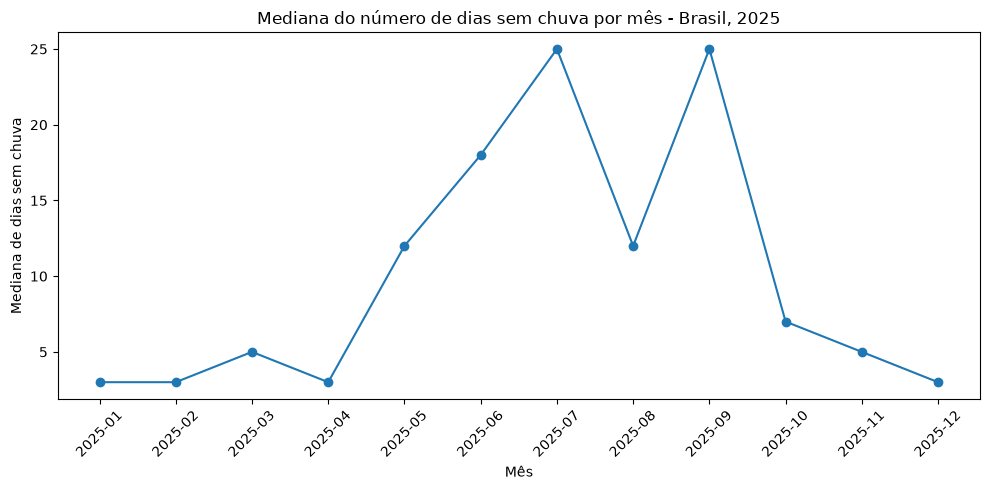

In [48]:
# Gráfico da mediana de dias sem chuva ao longo dos meses

plt.figure(figsize=(10, 5))

plt.plot(
    tabela_dias_sem_chuva_mes["data_pas_dt"],
    tabela_dias_sem_chuva_mes["mediana"],
    marker="o"
)

plt.title("Mediana do número de dias sem chuva por mês - Brasil, 2025")
plt.xlabel("Mês")
plt.ylabel("Mediana de dias sem chuva")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 5.1.2 Observação sobre o número de dias sem chuva ao longo dos meses

Conforme a tabela apresentada na seção 5.1, a mediana do número de dias sem
chuva apresentou valores mais baixos nos primeiros meses do ano. A partir de
maio foram observados valores mais altos em comparação ao início do ano, com
as maiores medianas em julho e setembro, ambos com 25 dias.

Após setembro, a mediana diminuiu, chegando a 7 dias em outubro, 5 dias em
novembro e 3 dias em dezembro.

O gráfico apresentado na seção 5.1.1 permite visualizar essa variação ao longo
dos meses de 2025.

### 5.2 Precipitação ao longo dos meses

Nesta análise será observada a precipitação média associada aos registros
em cada mês de 2025. A comparação mensal permite verificar como os
valores dessa variável se comportam ao longo do período analisado.

In [49]:
# Resumo mensal da precipitação
tabela_precipitacao_mes = (
    df_eda
    .groupby(df_eda["data_pas_dt"].dt.to_period("M"))["precipitacao"]
    .agg(
        media="mean",
        registros_validos="count"
    )
    .reset_index()
)

tabela_precipitacao_mes["data_pas_dt"] = (
    tabela_precipitacao_mes["data_pas_dt"].astype(str)
)

tabela_precipitacao_mes["media"] = (
    tabela_precipitacao_mes["media"].round(2)
)

tabela_precipitacao_mes

,data_pas_dt,media,registros_validos
0,2025-01,2.02,63439
1,2025-02,1.52,41395
2,2025-03,1.12,49888
3,2025-04,1.41,29801
4,2025-05,0.22,107679
5,2025-06,0.13,168163
6,2025-07,0.25,243608
7,2025-08,0.21,594309
8,2025-09,0.38,833039
9,2025-10,0.53,823480


#### 5.2.1 Visualização da precipitação ao longo dos meses

A visualização mensal permite comparar a precipitação média associada aos
registros em cada mês de 2025 e observar como os valores variam ao longo
do período analisado.

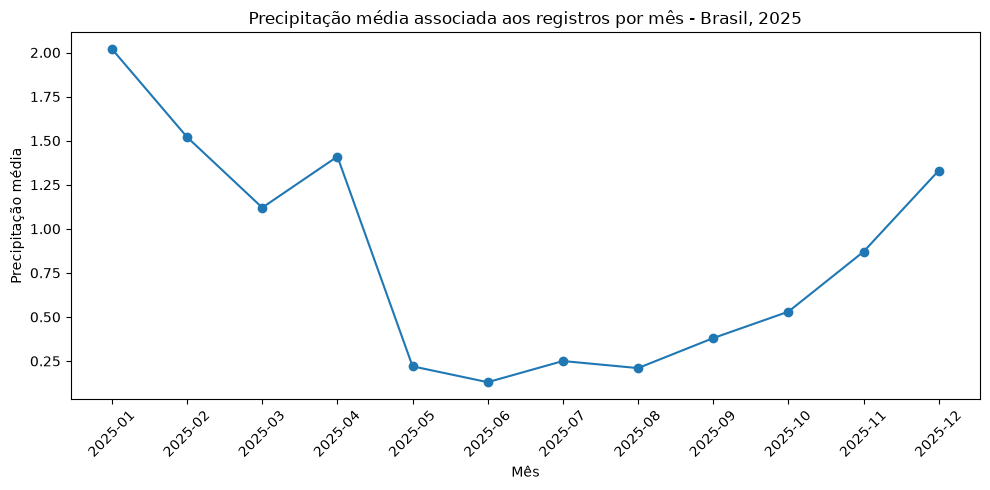

In [50]:
# Gráfico da precipitação média ao longo dos meses

plt.figure(figsize=(10, 5))

plt.plot(
    tabela_precipitacao_mes["data_pas_dt"],
    tabela_precipitacao_mes["media"],
    marker="o"
)

plt.title("Precipitação média associada aos registros por mês - Brasil, 2025")
plt.xlabel("Mês")
plt.ylabel("Precipitação média")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 5.2.2 Observação sobre a precipitação ao longo dos meses

Conforme a tabela apresentada na seção 5.2, a precipitação média associada aos
registros apresentou valores mais altos no início do ano, com 2,02 em
janeiro. Os menores valores foram observados entre maio e agosto, com destaque
para junho, que apresentou média de 0,13.

A partir de setembro, os valores aumentaram novamente, chegando a 1,33 em
dezembro.

O gráfico apresentado na seção 5.2.1 permite visualizar essa variação ao longo
dos meses de 2025.

### 5.3 Risco de fogo ao longo dos meses

Nesta análise será observado o risco de fogo médio associado aos registros
em cada mês de 2025. A comparação mensal permite verificar como
essa variável se comporta ao longo do período analisado.

In [51]:
# Resumo mensal do risco de fogo
tabela_risco_fogo_mes = (
    df_eda
    .groupby(df_eda["data_pas_dt"].dt.to_period("M"))["risco_fogo"]
    .agg(
        media="mean",
        registros_validos="count"
    )
    .reset_index()
)

tabela_risco_fogo_mes["data_pas_dt"] = (
    tabela_risco_fogo_mes["data_pas_dt"].astype(str)
)

tabela_risco_fogo_mes["media"] = (
    tabela_risco_fogo_mes["media"].round(2)
)

tabela_risco_fogo_mes

,data_pas_dt,media,registros_validos
0,2025-01,0.51,62070
1,2025-02,0.40,40075
2,2025-03,0.52,48408
3,2025-04,0.50,29075
4,2025-05,0.66,106333
5,2025-06,0.77,166342
6,2025-07,0.87,240997
7,2025-08,0.86,589941
8,2025-09,0.90,827775
9,2025-10,0.84,819617


#### 5.3.1 Visualização do risco de fogo ao longo dos meses

A visualização mensal permite comparar o risco de fogo médio associado aos
registros em cada mês de 2025 e observar como essa variável se
comporta ao longo do ano.

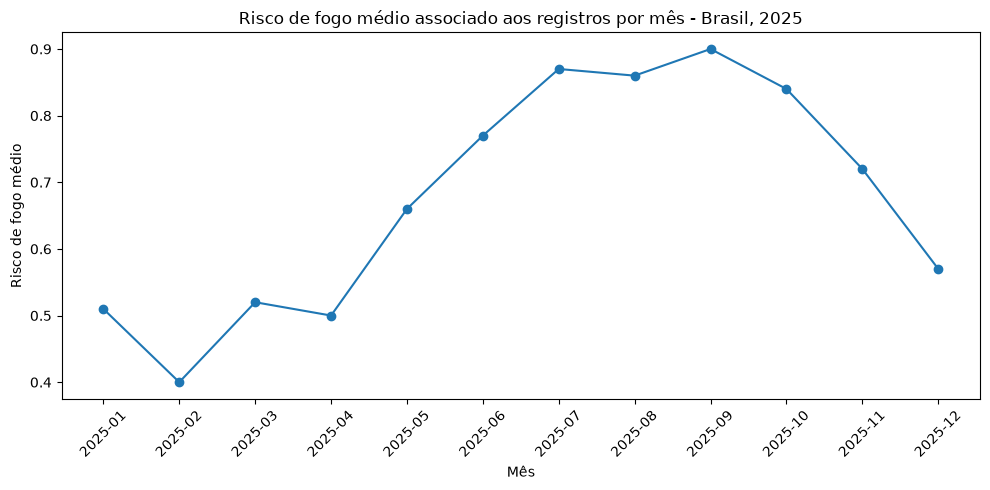

In [52]:
# Gráfico do risco de fogo médio ao longo dos meses

plt.figure(figsize=(10, 5))

plt.plot(
    tabela_risco_fogo_mes["data_pas_dt"],
    tabela_risco_fogo_mes["media"],
    marker="o"
)

plt.title("Risco de fogo médio associado aos registros por mês - Brasil, 2025")
plt.xlabel("Mês")
plt.ylabel("Risco de fogo médio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 5.3.2 Observação sobre o risco de fogo ao longo dos meses

Conforme a tabela apresentada na seção 5.3, o risco de fogo médio associado
aos registros apresentou valores mais altos a partir de maio. Os maiores
valores foram observados entre julho e outubro, com o maior valor em setembro,
quando a média foi de 0,90.

Após setembro, os valores diminuíram, passando para 0,84 em outubro, 0,72 em
novembro e 0,57 em dezembro.

O gráfico apresentado na seção 5.3.1 permite visualizar essa variação ao longo
dos meses de 2025.

### 5.4 Comparação das condições ambientais ao longo dos meses

Nesta etapa serão reunidos os resultados mensais de número de dias sem chuva,
precipitação e risco de fogo. O objetivo é comparar o comportamento dessas
variáveis ao longo de 2025, sem estabelecer relação de causa e efeito entre elas.

Os cálculos mensais consideram apenas os valores válidos de cada variável.
Por isso, a quantidade de registros utilizada pode variar entre as análises.

In [53]:
# Comparação mensal das condições ambientais
tabela_condicoes_mes = pd.DataFrame({
    "mes": tabela_dias_sem_chuva_mes["data_pas_dt"],
    "mediana_dias_sem_chuva": tabela_dias_sem_chuva_mes["mediana"],
    "precipitacao_media": tabela_precipitacao_mes["media"],
    "risco_fogo_medio": tabela_risco_fogo_mes["media"]
})

tabela_condicoes_mes

,mes,mediana_dias_sem_chuva,precipitacao_media,risco_fogo_medio
0,2025-01,3.0,2.02,0.51
1,2025-02,3.0,1.52,0.40
2,2025-03,5.0,1.12,0.52
3,2025-04,3.0,1.41,0.50
4,2025-05,12.0,0.22,0.66
5,2025-06,18.0,0.13,0.77
6,2025-07,25.0,0.25,0.87
7,2025-08,12.0,0.21,0.86
8,2025-09,25.0,0.38,0.90
9,2025-10,7.0,0.53,0.84


#### 5.4.1 Observação sobre as condições ambientais ao longo dos meses

Conforme a tabela apresentada na seção 5.4, entre maio e setembro foram
observados, de modo geral, valores maiores de dias sem chuva, menores valores
de precipitação média e valores mais altos de risco de fogo.

Em julho e setembro, a mediana do número de dias sem chuva chegou a 25 dias.
Nesse mesmo período, o risco de fogo médio apresentou valores elevados,
chegando a 0,90 em setembro. A precipitação média permaneceu relativamente
baixa nesses meses quando comparada ao início e ao final do ano.

A comparação permite observar que essas variáveis apresentam mudanças ao
longo dos mesmos períodos de 2025. No entanto, esta análise exploratória não
permite afirmar que uma dessas condições seja a causa direta das demais.

## 6. Principais resultados da Análise Exploratória de Dados

Nesta seção são reunidos os principais resultados encontrados durante a análise
exploratória dos dados. As observações apresentadas a seguir utilizam os
resultados já calculados nas etapas anteriores e estão organizadas de acordo
com os aspectos temporal, territorial, ambiental e de qualidade dos dados.

### 6.1 Resultados temporais

Conforme a análise temporal apresentada na seção 2.2, os registros
não se distribuíram de forma uniforme ao longo de 2025. A maior quantidade
foi observada em setembro, com 833.039 registros, correspondendo a 24,03% do
total, seguida por outubro, com 823.767 registros e 23,76%.

Os resultados mostram maior concentração de registros entre agosto e outubro,
enquanto os primeiros meses do ano apresentaram quantidades menores. O gráfico
apresentado na seção 2.2.1 permite visualizar essa diferença ao longo do ano.

### 6.2 Resultados territoriais

Conforme a análise apresentada na seção 4.1, o Maranhão apresentou a maior
quantidade de registros entre os estados, com 588.744 registros,
correspondendo a 16,98% do total analisado.

Na análise por bioma, apresentada na seção 4.2, o Cerrado concentrou a maior
quantidade de registros, com 1.784.865 registros, representando 51,49% do total.
Na sequência aparecem Amazônia e Caatinga.

Entre os municípios analisados na seção 4.3, Colniza, em Mato Grosso,
apresentou a maior quantidade de registros, com 42.141 registros,
correspondendo a 1,22% do total. Mirador, no Maranhão, e Paranã, no Tocantins,
aparecem na sequência entre os municípios com maior quantidade de registros.

### 6.3 Resultados das condições ambientais

Conforme as análises apresentadas na seção 5, as variáveis ambientais
apresentaram mudanças ao longo de 2025. O número de dias sem chuva apresentou
valores mais altos em parte do período entre maio e setembro, com mediana de
25 dias em julho e setembro.

A precipitação média associada aos registros apresentou valores mais baixos
entre maio e agosto, enquanto o risco de fogo médio apresentou valores mais
altos entre julho e outubro, atingindo 0,90 em setembro.

A comparação apresentada na seção 5.4 mostra que essas variações ocorreram em
períodos próximos ao longo do ano. No entanto, a análise exploratória não
permite afirmar relação de causa e efeito entre essas variáveis.

### 6.4 Qualidade dos dados

Durante a análise de qualidade dos dados foram identificados valores ausentes,
registros duplicados e valores especiais em algumas variáveis.

Na verificação inicial da base, as variáveis `numero_dias_sem_chuva`,
`precipitacao` e `risco_fogo` apresentaram 58.485 valores ausentes cada,
correspondendo a 1,69% dos registros. A variável `frp` apresentou 45.481
valores ausentes, equivalentes a 1,31% do total.

Também foram identificados 585 registros duplicados. Além disso, foram
encontrados valores -999 nas variáveis `numero_dias_sem_chuva` e `risco_fogo`.

Conforme a documentação utilizada do Programa Queimadas do INPE, esses valores
foram considerados inválidos. Na base preparada para análise (`df_eda`), os
valores -999 foram substituídos por valores ausentes, sem alterar a base
original carregada no DataFrame `df`.

Os detalhes dessas verificações e tratamentos foram apresentados nas seções
2 e 3 do notebook.

### 6.5 Síntese da Análise Exploratória

A análise exploratória permitiu conhecer melhor o conjunto de dados e
identificar características importantes dos registros analisados no Brasil
em 2025.

Os resultados mostraram diferenças na distribuição dos registros ao longo dos
meses, entre estados, biomas e municípios. Também foram observadas mudanças
nas variáveis relacionadas ao número de dias sem chuva, precipitação e risco
de fogo ao longo do ano.

Além disso, a análise permitiu identificar valores ausentes, registros
duplicados e valores inválidos em algumas variáveis. Os valores -999
identificados em `numero_dias_sem_chuva` e `risco_fogo` foram tratados como
ausentes na base preparada para análise.

Os resultados obtidos nesta etapa serão utilizados como apoio para a definição
da proposta analítica do projeto.

Os resultados obtidos nesta etapa serão utilizados como apoio para a definição
da proposta analítica do projeto.